In [9]:
# Imports
import duckdb
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

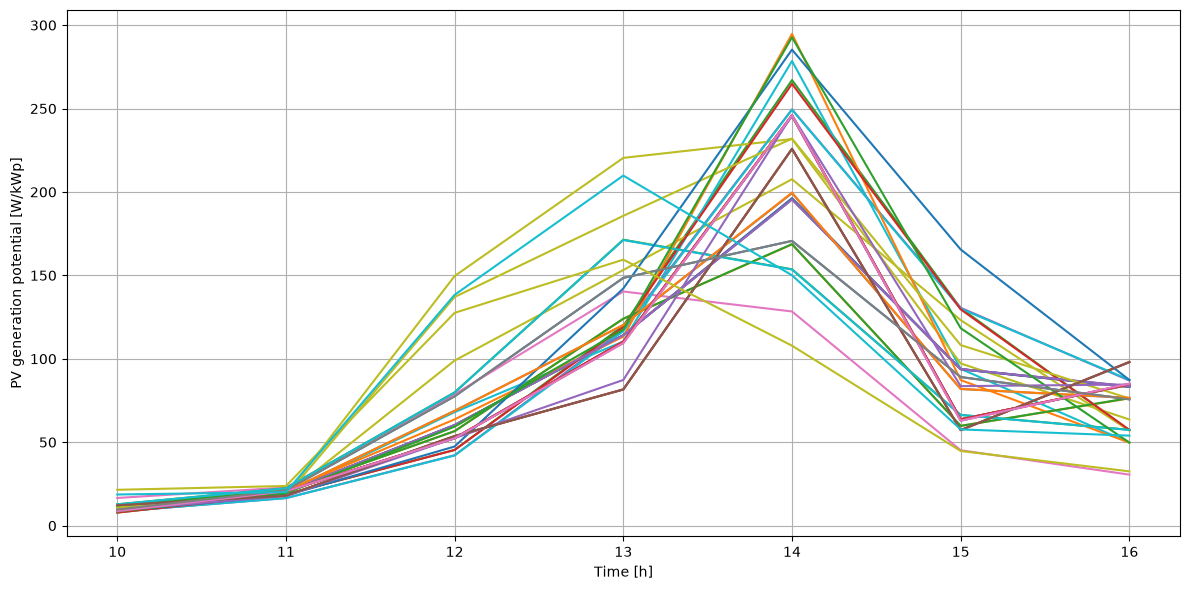

Saved: C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots\2024-01-22_solar_power_v6_raw.pdf


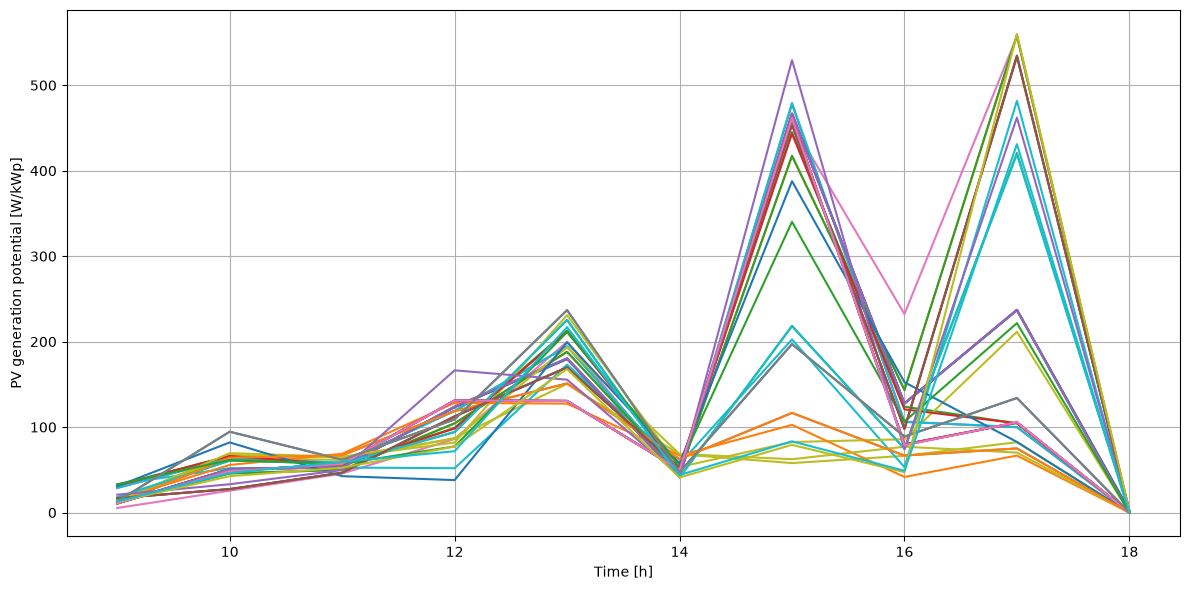

Saved: C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots\2024-02-22_solar_power_v6_raw.pdf


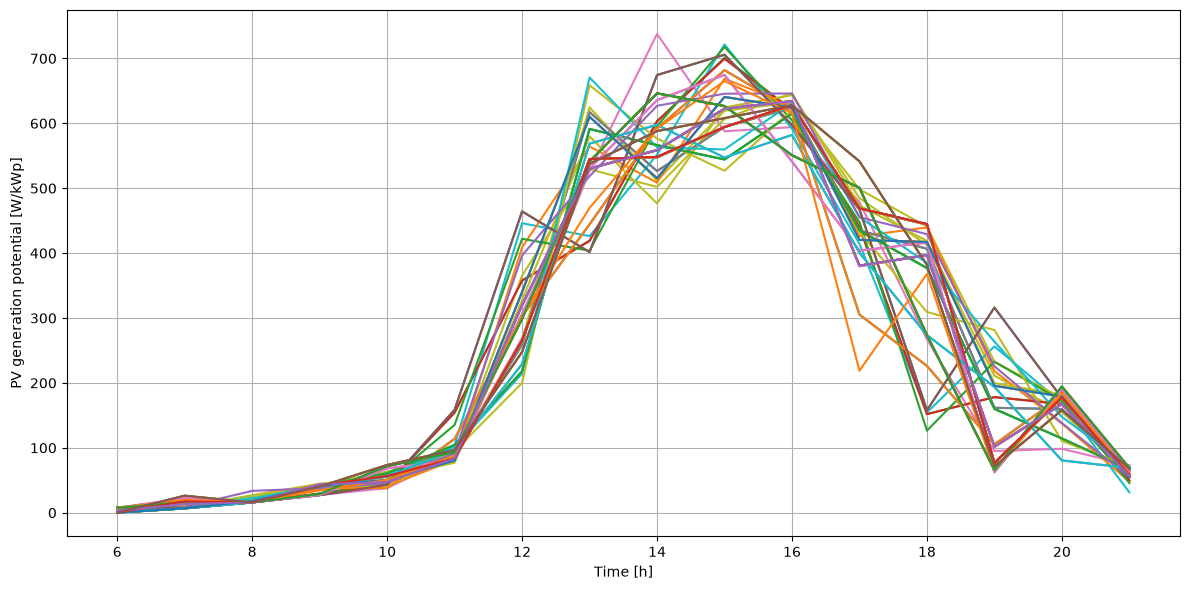

Saved: C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots\2024-06-22_solar_power_v6_raw.pdf


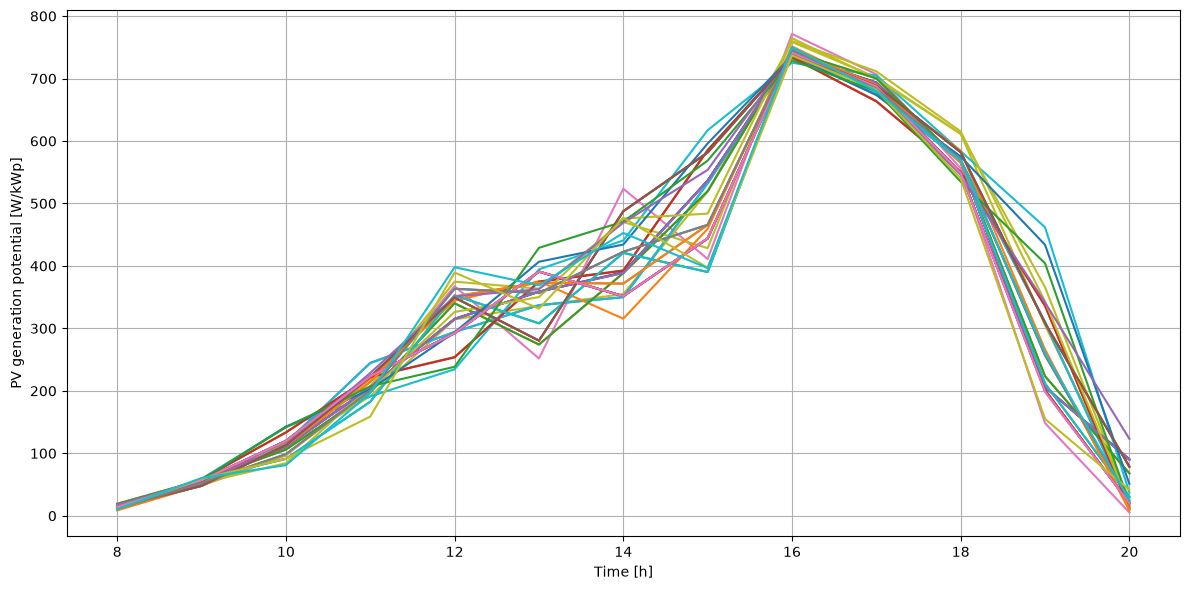

Saved: C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots\2024-08-22_solar_power_v6_raw.pdf


In [21]:
directory = Path("../../pv_estimation/data")
output_directory = Path(r"C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots")

name = "solar_power_v6_raw.csv"

for file in directory.glob(f"????-??-??_{name}"):

    df = pd.read_csv(file)

    # Time columns are everything after station_id and peak_power
    time_columns = df.columns[2:]

    # Convert time from seconds to hours
    time = pd.to_numeric(time_columns) / 3600

    # Convert production values to numeric
    production = df[time_columns].apply(pd.to_numeric)

    # Keep only hours where at least one station produces power
    non_zero_hours = production.max(axis=0) > 0

    time_columns_filtered = time_columns[non_zero_hours]
    time_filtered = time[non_zero_hours]
    production_filtered = production.loc[:, non_zero_hours]

    fig, ax = plt.subplots(figsize=(12, 6))

    for i, row in df.iterrows():
        pv_generation = production_filtered.iloc[i]

        ax.plot(
            time_filtered,
            pv_generation,
            label=f"Station {row['station_id']}"
        )

    ax.set_xlabel("Time [h]")
    ax.set_ylabel("PV generation potential [W/kWp]")
    ax.grid(True)

    fig.tight_layout()

    # Use the date from the input filename
    output_file = output_directory / f"{file.stem}.pdf"

    fig.savefig(
        output_file,
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(f"Saved: {output_file}")